[Alzheimer’s Prediction Dataset (Global)](https://www.kaggle.com/datasets/ankushpanday1/alzheimers-prediction-dataset-global)

## Data Card

### About Datset

**Introduction**
This dataset contains 74,283 records from 20 countries, providing insights into Alzheimer's disease risk factors. It includes demographic, lifestyle, medical, and genetic variables, with a biased distribution to reflect real-world disparities across regions.

This dataset is useful for predictive modeling, epidemiological studies, and healthcare research on Alzheimer’s disease.

**Authors**
Ankush Panday

**License**
MIT

In [2]:
import pandas as pd
import seaborn as sns
sns.set_palette("pastel")
import plotly.express as px
import plotly.io as pio
import matplotlib.pyplot as plt
import math
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.metrics import classification_report
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
#from xgboost import XGBClassifier
#from catboost import CatBoostClassifier
from sklearn.model_selection import GridSearchCV
pd.set_option('display.max_columns', None)
import warnings
warnings.filterwarnings('ignore', category=FutureWarning)
%matplotlib inline

In [61]:
df = pd.read_csv("data/alzheimers_disease_data.csv")

## Data Analysis

,PatientID,Age,Gender,Ethnicity,EducationLevel,BMI,Smoking,AlcoholConsumption,PhysicalActivity,DietQuality,SleepQuality,FamilyHistoryAlzheimers,CardiovascularDisease,Diabetes,Depression,HeadInjury,Hypertension,SystolicBP,DiastolicBP,CholesterolTotal,CholesterolLDL,CholesterolHDL,CholesterolTriglycerides,MMSE,FunctionalAssessment,MemoryComplaints,BehavioralProblems,ADL,Confusion,Disorientation,PersonalityChanges,DifficultyCompletingTasks,Forgetfulness,Diagnosis,DoctorInCharge
0,4751,73,0,0,2,22.927749,0,13.297218,6.327112,1.347214,9.025679,0,0,1,1,0,0,142,72,242.366840,56.150897,33.682563,162.189143,21.463532,6.518877,0,0,1.725883,0,0,0,1,0,0,XXXConfid
1,4752,89,0,0,0,26.827681,0,4.542524,7.619885,0.518767,7.151293,0,0,0,0,0,0,115,64,231.162595,193.407996,79.028477,294.630909,20.613267,7.118696,0,0,2.592424,0,0,0,0,1,0,XXXConfid
2,4753,73,0,3,1,17.795882,0,19.555085,7.844988,1.826335,9.673574,1,0,0,0,0,0,99,116,284.181858,153.322762,69.772292,83.638324,7.356249,5.895077,0,0,7.119548,0,1,0,1,0,0,XXXConfid
3,4754,74,1,0,1,33.800817,1,12.209266,8.428001,7.435604,8.392554,0,0,0,0,0,0,118,115,159.582240,65.366637,68.457491,277.577358,13.991127,8.965106,0,1,6.481226,0,0,0,0,0,0,XXXConfid
4,4755,89,0,0,0,20.716974,0,18.454356,6.310461,0.795498,5.597238,0,0,0,0,0,0,94,117,237.602184,92.869700,56.874305,291.198780,13.517609,6.045039,0,0,0.014691,0,0,1,1,0,0,XXXConfid


In [11]:

df = df.drop(columns=["PatientID","DoctorInCharge"])

In [39]:
df.head()

,Age,Gender,Ethnicity,EducationLevel,BMI,Smoking,AlcoholConsumption,PhysicalActivity,DietQuality,SleepQuality,FamilyHistoryAlzheimers,CardiovascularDisease,Diabetes,Depression,HeadInjury,Hypertension,SystolicBP,DiastolicBP,CholesterolTotal,CholesterolLDL,CholesterolHDL,CholesterolTriglycerides,MMSE,FunctionalAssessment,MemoryComplaints,BehavioralProblems,ADL,Confusion,Disorientation,PersonalityChanges,DifficultyCompletingTasks,Forgetfulness,Diagnosis
0,73,0,0,2,22.927749,0,13.297218,6.327112,1.347214,9.025679,0,0,1,1,0,0,142,72,242.366840,56.150897,33.682563,162.189143,21.463532,6.518877,0,0,1.725883,0,0,0,1,0,0
1,89,0,0,0,26.827681,0,4.542524,7.619885,0.518767,7.151293,0,0,0,0,0,0,115,64,231.162595,193.407996,79.028477,294.630909,20.613267,7.118696,0,0,2.592424,0,0,0,0,1,0
2,73,0,3,1,17.795882,0,19.555085,7.844988,1.826335,9.673574,1,0,0,0,0,0,99,116,284.181858,153.322762,69.772292,83.638324,7.356249,5.895077,0,0,7.119548,0,1,0,1,0,0
3,74,1,0,1,33.800817,1,12.209266,8.428001,7.435604,8.392554,0,0,0,0,0,0,118,115,159.582240,65.366637,68.457491,277.577358,13.991127,8.965106,0,1,6.481226,0,0,0,0,0,0
4,89,0,0,0,20.716974,0,18.454356,6.310461,0.795498,5.597238,0,0,0,0,0,0,94,117,237.602184,92.869700,56.874305,291.198780,13.517609,6.045039,0,0,0.014691,0,0,1,1,0,0


In [12]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2149 entries, 0 to 2148
Data columns (total 33 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Age                        2149 non-null   int64  
 1   Gender                     2149 non-null   int64  
 2   Ethnicity                  2149 non-null   int64  
 3   EducationLevel             2149 non-null   int64  
 4   BMI                        2149 non-null   float64
 5   Smoking                    2149 non-null   int64  
 6   AlcoholConsumption         2149 non-null   float64
 7   PhysicalActivity           2149 non-null   float64
 8   DietQuality                2149 non-null   float64
 9   SleepQuality               2149 non-null   float64
 10  FamilyHistoryAlzheimers    2149 non-null   int64  
 11  CardiovascularDisease      2149 non-null   int64  
 12  Diabetes                   2149 non-null   int64  
 13  Depression                 2149 non-null   int64  
 14  Hea

In [30]:
df.isnull().sum()

Age                          0
Gender                       0
Ethnicity                    0
EducationLevel               0
BMI                          0
Smoking                      0
AlcoholConsumption           0
PhysicalActivity             0
DietQuality                  0
SleepQuality                 0
FamilyHistoryAlzheimers      0
CardiovascularDisease        0
Diabetes                     0
Depression                   0
HeadInjury                   0
Hypertension                 0
SystolicBP                   0
DiastolicBP                  0
CholesterolTotal             0
CholesterolLDL               0
CholesterolHDL               0
CholesterolTriglycerides     0
MMSE                         0
FunctionalAssessment         0
MemoryComplaints             0
BehavioralProblems           0
ADL                          0
Confusion                    0
Disorientation               0
PersonalityChanges           0
DifficultyCompletingTasks    0
Forgetfulness                0
Diagnosi

In [13]:
df.duplicated().sum()

np.int64(0)

In [21]:
df.columns

Index(['Age', 'Gender', 'Ethnicity', 'EducationLevel', 'BMI', 'Smoking',
       'AlcoholConsumption', 'PhysicalActivity', 'DietQuality', 'SleepQuality',
       'FamilyHistoryAlzheimers', 'CardiovascularDisease', 'Diabetes',
       'Depression', 'HeadInjury', 'Hypertension', 'SystolicBP', 'DiastolicBP',
       'CholesterolTotal', 'CholesterolLDL', 'CholesterolHDL',
       'CholesterolTriglycerides', 'MMSE', 'FunctionalAssessment',
       'MemoryComplaints', 'BehavioralProblems', 'ADL', 'Confusion',
       'Disorientation', 'PersonalityChanges', 'DifficultyCompletingTasks',
       'Forgetfulness', 'Diagnosis'],
      dtype='str')

In [36]:
df['Diagnosis']

0       0
1       0
2       0
3       0
4       0
       ..
2144    1
2145    1
2146    1
2147    1
2148    0
Name: Diagnosis, Length: 2149, dtype: int64

In [14]:
def histogram(df, label,rotation=None):
    ax = sns.histplot(data=df,x=label,hue=label,legend=False, shrink=.9)
    if rotation:
        ax.tick_params(axis='x', labelrotation=rotation)
    # Add the counts on top of each bar automatically
    for container in ax.containers:
        ax.bar_label(container, fmt=lambda x: str(int(x)) if x > 0 else '')
    image_title = label.replace(" ", "_")
    plt.savefig(image_title, dpi=300, bbox_inches="tight")
    plt.show()

In [15]:
def histogram_totals(totals,title,xlabel):
    labels = ['Yes', 'No']   
    # 2. Create the bar plot
    plt.figure(figsize=(6, 4))
    ax = sns.barplot(x=labels, y=totals, palette=['#a1c9f4', '#ffb482'])
    for container in ax.containers:
            ax.bar_label(container, fmt=lambda x: str(int(x)) if x > 0 else '')
    # 3. Add labels and show
    plt.title(title)
    image_title = title.replace(" ", "_")
    plt.savefig(image_title, dpi=300, bbox_inches="tight")
    plt.xlabel(xlabel)
    plt.ylabel("Count")
    plt.show()

In [16]:
def binary_plot(df,label,title=None):
    if not title:
        title = label
    df_copy = df.copy()
    df_copy[label] = df_copy[label].replace({0: 'no', 1: 'yes'})
    sns.countplot(data=df_copy, x=label,order=['yes', 'no'], palette=['#a1c9f4', '#ffb482'])
    plt.title(title)
    plt.show()

In [17]:
def yesno_plot(df,label,title=None):
    if not title:
        title = label
        
    sns.countplot(data=df, x=label, palette=['#a1c9f4', '#ffb482'])
    plt.title(title)
    plt.show()

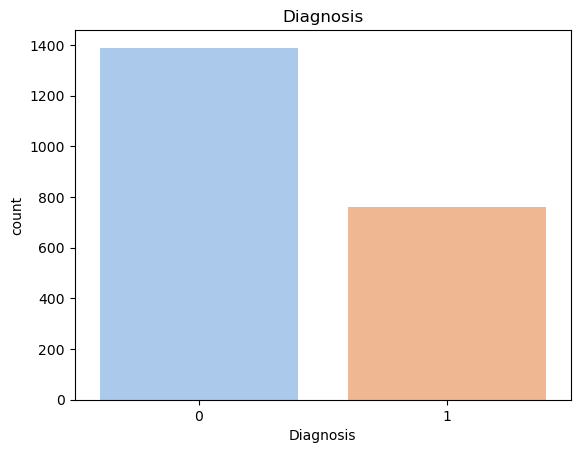

In [22]:
yesno_plot(df,"Diagnosis")

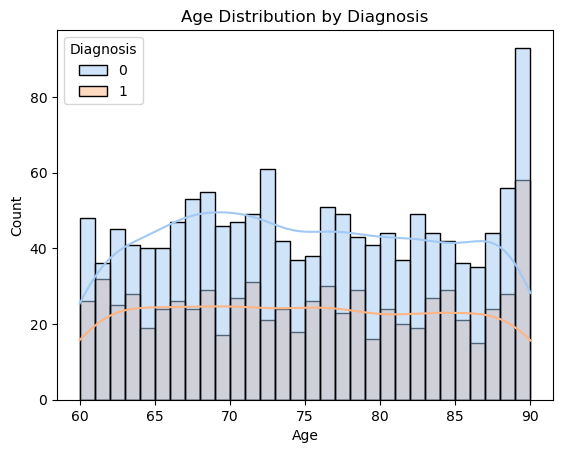

In [28]:
sns.histplot(
    data=df,
    x="Age",
    hue="Diagnosis",
    bins=30,
    kde=True
)
plt.title("Age Distribution by Diagnosis")
plt.show()

In [40]:
def pie(label,title=None):
    if not title:
        title = label

    val=df[label][df['Diagnosis']==1].value_counts().values
    index=df[label][df['Diagnosis']==1].value_counts().index
    fig = px.pie(values=val,names=index,title=title,width=400, height=400).update_traces(textinfo='label+percent')
    fig.show()

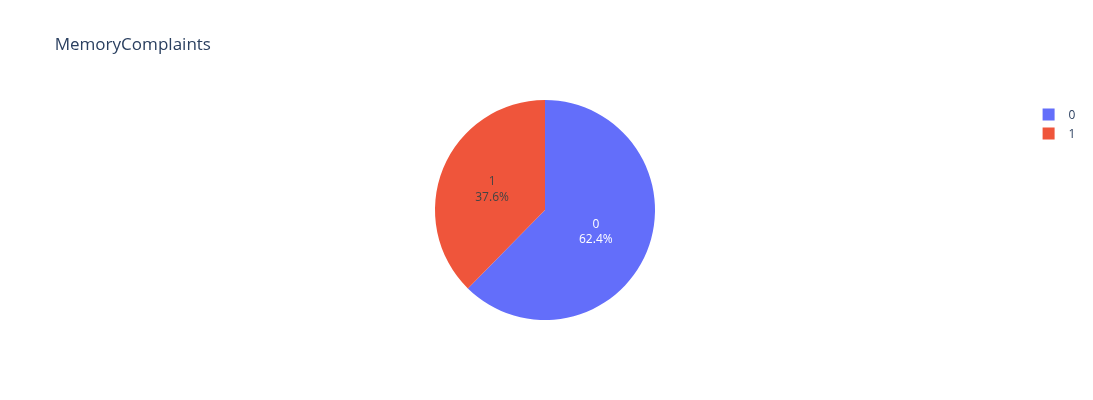

In [41]:
pie('MemoryComplaints')

In [42]:
categorical_df = df.select_dtypes(include='int')
categorical_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2149 entries, 0 to 2148
Data columns (total 21 columns):
 #   Column                     Non-Null Count  Dtype
---  ------                     --------------  -----
 0   Age                        2149 non-null   int64
 1   Gender                     2149 non-null   int64
 2   Ethnicity                  2149 non-null   int64
 3   EducationLevel             2149 non-null   int64
 4   Smoking                    2149 non-null   int64
 5   FamilyHistoryAlzheimers    2149 non-null   int64
 6   CardiovascularDisease      2149 non-null   int64
 7   Diabetes                   2149 non-null   int64
 8   Depression                 2149 non-null   int64
 9   HeadInjury                 2149 non-null   int64
 10  Hypertension               2149 non-null   int64
 11  SystolicBP                 2149 non-null   int64
 12  DiastolicBP                2149 non-null   int64
 13  MemoryComplaints           2149 non-null   int64
 14  BehavioralProblems         2149 non

In [43]:
categorical_df_positive = categorical_df[categorical_df["Diagnosis"] == "Yes"]
categorical_positive_dicts = dict()

for i, column in enumerate(categorical_df_positive, 1):
    if column != "Country" and column != "Diagnosis":
        item = categorical_df[column].value_counts().to_dict()
        categorical_positive_dicts[column] = item

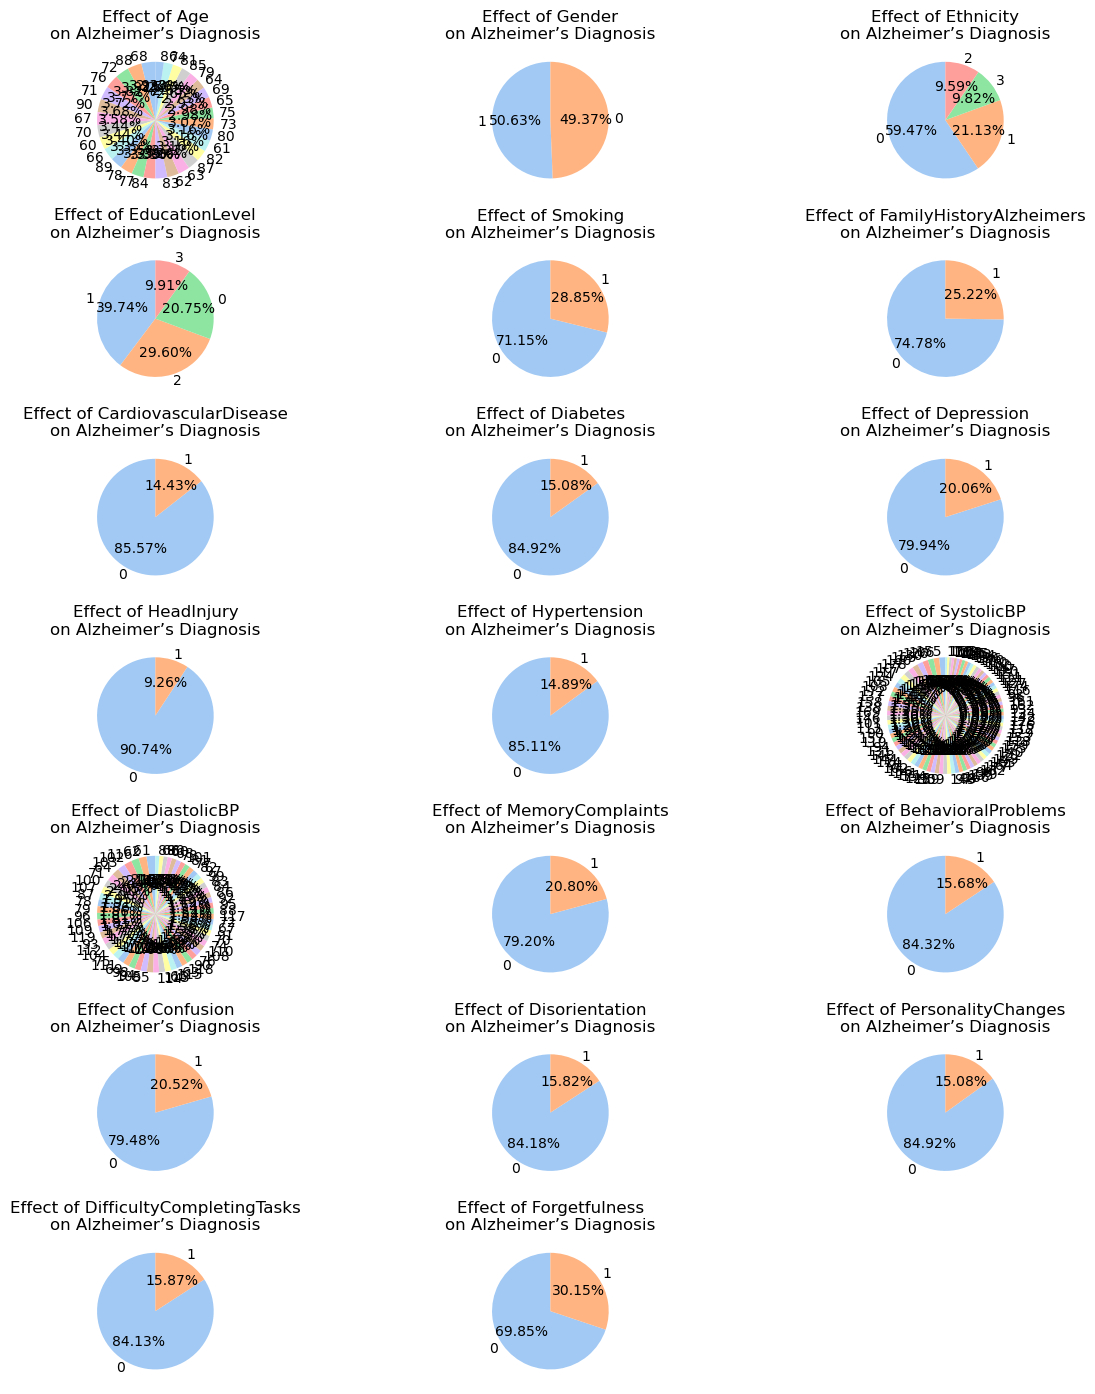

In [44]:
plt.figure(figsize=[12, 20])
i = 1

for key, value in categorical_positive_dicts.items():
    plt.subplot(10, 3, i)
    plt.pie(value.values(), labels=value.keys(), startangle=90, autopct="%.2f%%")
    plt.title("Effect of {}\non Alzheimer’s Diagnosis".format(key))
    i = i + 1

plt.tight_layout()
plt.show()

In [124]:
df.columns

Index(['Country', 'Age', 'Gender', 'Education Level', 'BMI',
       'Physical Activity Level', 'Smoking Status', 'Alcohol Consumption',
       'Diabetes', 'Hypertension', 'Cholesterol Level',
       'Family History of Alzheimer’s', 'Cognitive Test Score',
       'Depression Level', 'Sleep Quality', 'Dietary Habits',
       'Air Pollution Exposure', 'Employment Status', 'Marital Status',
       'Genetic Risk Factor (APOE-ε4 allele)', 'Social Engagement Level',
       'Income Level', 'Stress Levels', 'Urban vs Rural Living',
       'Alzheimer’s Diagnosis'],
      dtype='str')

In [45]:
y = df['Diagnosis']


In [46]:
X = df.drop(columns='Diagnosis')

In [47]:
X

,Age,Gender,Ethnicity,EducationLevel,BMI,Smoking,AlcoholConsumption,PhysicalActivity,DietQuality,SleepQuality,FamilyHistoryAlzheimers,CardiovascularDisease,Diabetes,Depression,HeadInjury,Hypertension,SystolicBP,DiastolicBP,CholesterolTotal,CholesterolLDL,CholesterolHDL,CholesterolTriglycerides,MMSE,FunctionalAssessment,MemoryComplaints,BehavioralProblems,ADL,Confusion,Disorientation,PersonalityChanges,DifficultyCompletingTasks,Forgetfulness
0,73,0,0,2,22.927749,0,13.297218,6.327112,1.347214,9.025679,0,0,1,1,0,0,142,72,242.366840,56.150897,33.682563,162.189143,21.463532,6.518877,0,0,1.725883,0,0,0,1,0
1,89,0,0,0,26.827681,0,4.542524,7.619885,0.518767,7.151293,0,0,0,0,0,0,115,64,231.162595,193.407996,79.028477,294.630909,20.613267,7.118696,0,0,2.592424,0,0,0,0,1
2,73,0,3,1,17.795882,0,19.555085,7.844988,1.826335,9.673574,1,0,0,0,0,0,99,116,284.181858,153.322762,69.772292,83.638324,7.356249,5.895077,0,0,7.119548,0,1,0,1,0
3,74,1,0,1,33.800817,1,12.209266,8.428001,7.435604,8.392554,0,0,0,0,0,0,118,115,159.582240,65.366637,68.457491,277.577358,13.991127,8.965106,0,1,6.481226,0,0,0,0,0
4,89,0,0,0,20.716974,0,18.454356,6.310461,0.795498,5.597238,0,0,0,0,0,0,94,117,237.602184,92.869700,56.874305,291.198780,13.517609,6.045039,0,0,0.014691,0,0,1,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2144,61,0,0,1,39.121757,0,1.561126,4.049964,6.555306,7.535540,0,0,0,0,0,0,122,101,280.476824,94.870490,60.943092,234.520123,1.201190,0.238667,0,0,4.492838,1,0,0,0,0
2145,75,0,0,2,17.857903,0,18.767261,1.360667,2.904662,8.555256,0,0,0,0,0,0,152,106,186.384436,95.410700,93.649735,367.986877,6.458060,8.687480,0,1,9.204952,0,0,0,0,0
2146,77,0,0,1,15.476479,0,4.594670,9.886002,8.120025,5.769464,0,0,0,0,0,0,115,118,237.024558,156.267294,99.678209,294.802338,17.011003,1.972137,0,0,5.036334,0,0,0,0,0
2147,78,1,3,1,15.299911,0,8.674505,6.354282,1.263427,8.322874,0,1,0,0,0,0,103,96,242.197192,52.482961,81.281111,145.253746,4.030491,5.173891,0,0,3.785399,0,0,0,0,1


In [48]:
df2 = pd.get_dummies(categorical_df, drop_first=True)
df2

,Age,Gender,Ethnicity,EducationLevel,Smoking,FamilyHistoryAlzheimers,CardiovascularDisease,Diabetes,Depression,HeadInjury,Hypertension,SystolicBP,DiastolicBP,MemoryComplaints,BehavioralProblems,Confusion,Disorientation,PersonalityChanges,DifficultyCompletingTasks,Forgetfulness,Diagnosis
0,73,0,0,2,0,0,0,1,1,0,0,142,72,0,0,0,0,0,1,0,0
1,89,0,0,0,0,0,0,0,0,0,0,115,64,0,0,0,0,0,0,1,0
2,73,0,3,1,0,1,0,0,0,0,0,99,116,0,0,0,1,0,1,0,0
3,74,1,0,1,1,0,0,0,0,0,0,118,115,0,1,0,0,0,0,0,0
4,89,0,0,0,0,0,0,0,0,0,0,94,117,0,0,0,0,1,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2144,61,0,0,1,0,0,0,0,0,0,0,122,101,0,0,1,0,0,0,0,1
2145,75,0,0,2,0,0,0,0,0,0,0,152,106,0,1,0,0,0,0,0,1
2146,77,0,0,1,0,0,0,0,0,0,0,115,118,0,0,0,0,0,0,0,1
2147,78,1,3,1,0,0,1,0,0,0,0,103,96,0,0,0,0,0,0,1,1


# Start Over

,Age,Gender,Ethnicity,EducationLevel,Smoking,FamilyHistoryAlzheimers,CardiovascularDisease,Diabetes,Depression,HeadInjury,Hypertension,SystolicBP,DiastolicBP,MemoryComplaints,BehavioralProblems,Confusion,Disorientation,PersonalityChanges,DifficultyCompletingTasks,Forgetfulness,Diagnosis
0,73,0,0,2,0,0,0,1,1,0,0,142,72,0,0,0,0,0,1,0,0
1,89,0,0,0,0,0,0,0,0,0,0,115,64,0,0,0,0,0,0,1,0
2,73,0,3,1,0,1,0,0,0,0,0,99,116,0,0,0,1,0,1,0,0
3,74,1,0,1,1,0,0,0,0,0,0,118,115,0,1,0,0,0,0,0,0
4,89,0,0,0,0,0,0,0,0,0,0,94,117,0,0,0,0,1,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2144,61,0,0,1,0,0,0,0,0,0,0,122,101,0,0,1,0,0,0,0,1
2145,75,0,0,2,0,0,0,0,0,0,0,152,106,0,1,0,0,0,0,0,1
2146,77,0,0,1,0,0,0,0,0,0,0,115,118,0,0,0,0,0,0,0,1
2147,78,1,3,1,0,0,1,0,0,0,0,103,96,0,0,0,0,0,0,1,1


In [50]:
y = df["Diagnosis"]
X =  df.drop(columns='Diagnosis')

In [51]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [52]:
import time
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, roc_auc_score, confusion_matrix, classification_report)

# Scale features (needed for LogReg + KNN; RF/GBM are scale-invariant)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

results = []

def evaluate(name, model, Xtr, Xte):
    start = time.time()
    model.fit(Xtr, y_train)
    fit_time = time.time() - start

    preds = model.predict(Xte)
    proba = model.predict_proba(Xte)[:, 1]

    row = {
        'Model': name,
        'Accuracy': accuracy_score(y_test, preds),
        'Precision': precision_score(y_test, preds),
        'Recall': recall_score(y_test, preds),
        'F1': f1_score(y_test, preds),
        'ROC-AUC': roc_auc_score(y_test, proba),
        'Fit Time (s)': round(fit_time, 2)
    }
    results.append(row)
    print(f"--- {name} ---")
    print(confusion_matrix(y_test, preds))
    print(classification_report(y_test, preds, target_names=['No', 'Yes']))
    return model

log_reg = evaluate('Logistic Regression', LogisticRegression(max_iter=1000, random_state=42),
                    X_train_scaled, X_test_scaled)

rf = evaluate('Random Forest', RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1),
              X_train, X_test)

gb = evaluate('Gradient Boosting', GradientBoostingClassifier(random_state=42),
              X_train, X_test)

knn = evaluate('KNN', KNeighborsClassifier(n_neighbors=15, n_jobs=-1),
               X_train_scaled, X_test_scaled)

results_df = pd.DataFrame(results).sort_values('ROC-AUC', ascending=False)
print(results_df.to_string(index=False))

--- Logistic Regression ---
[[239  39]
 [ 40 112]]
              precision    recall  f1-score   support

          No       0.86      0.86      0.86       278
         Yes       0.74      0.74      0.74       152

    accuracy                           0.82       430
   macro avg       0.80      0.80      0.80       430
weighted avg       0.82      0.82      0.82       430

--- Random Forest ---
[[270   8]
 [ 16 136]]
              precision    recall  f1-score   support

          No       0.94      0.97      0.96       278
         Yes       0.94      0.89      0.92       152

    accuracy                           0.94       430
   macro avg       0.94      0.93      0.94       430
weighted avg       0.94      0.94      0.94       430

--- Gradient Boosting ---
[[267  11]
 [ 12 140]]
              precision    recall  f1-score   support

          No       0.96      0.96      0.96       278
         Yes       0.93      0.92      0.92       152

    accuracy                         

# Drop the Biology

In [202]:
df = pd.read_csv("data/alzheimers_prediction_dataset.csv")
df.columns

Index(['Country', 'Age', 'Gender', 'Education Level', 'BMI',
       'Physical Activity Level', 'Smoking Status', 'Alcohol Consumption',
       'Diabetes', 'Hypertension', 'Cholesterol Level',
       'Family History of Alzheimer’s', 'Cognitive Test Score',
       'Depression Level', 'Sleep Quality', 'Dietary Habits',
       'Air Pollution Exposure', 'Employment Status', 'Marital Status',
       'Genetic Risk Factor (APOE-ε4 allele)', 'Social Engagement Level',
       'Income Level', 'Stress Levels', 'Urban vs Rural Living',
       'Alzheimer’s Diagnosis'],
      dtype='str')

In [54]:
# --- Drop the two genetic/family-history columns ---
df = df.drop(columns=['MMSE','Age'])

Final shape: (74283, 25)


In [55]:
y = df["Diagnosis"]
X =  df.drop(columns='Diagnosis')

In [56]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [70]:
def train(X_train, X_test, y_train, y_test): 

    # Scale features (needed for LogReg + KNN; RF/GBM are scale-invariant)
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    results = []
    
    def evaluate(name, model, Xtr, Xte):
        start = time.time()
        model.fit(Xtr, y_train)
        fit_time = time.time() - start
    
        preds = model.predict(Xte)
        proba = model.predict_proba(Xte)[:, 1]
    
        row = {
            'Model': name,
            'Accuracy': accuracy_score(y_test, preds),
            'Precision': precision_score(y_test, preds),
            'Recall': recall_score(y_test, preds),
            'F1': f1_score(y_test, preds),
            'ROC-AUC': roc_auc_score(y_test, proba),
            'Fit Time (s)': round(fit_time, 2)
        }
        results.append(row)
        print(f"--- {name} ---")
        print(confusion_matrix(y_test, preds))
        print(classification_report(y_test, preds, target_names=['No', 'Yes']))
        return model
    
    # Logistic Regression
    log_reg = evaluate('Logistic Regression', LogisticRegression(max_iter=1000, random_state=42),
                        X_train_scaled, X_test_scaled)
    lr_coef = pd.Series(log_reg.coef_[0], index=X.columns).sort_values(key=abs, ascending=False)
    
    # Random Forest
    rf = evaluate('Random Forest', RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1),
                  X_train, X_test)
    rf_imp = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)
    
    # Gradient Boosting
    gb = evaluate('Gradient Boosting', GradientBoostingClassifier(random_state=42),
                  X_train, X_test)
    gb_imp = pd.Series(gb.feature_importances_, index=X.columns).sort_values(ascending=False)
    
    
    knn = evaluate('KNN', KNeighborsClassifier(n_neighbors=15, n_jobs=-1),
                   X_train_scaled, X_test_scaled)
    
    results_df = pd.DataFrame(results).sort_values('ROC-AUC', ascending=False)
    print(results_df.to_string(index=False))
    print()
    print("=== Gradient Boosting: Top 15 Feature Importances ===")
    print(gb_imp.head(15))
    print()
    print("=== Random Forest: Top 15 Feature Importances ===")
    print(rf_imp.head(15))
    print()
    print("=== Logistic Regression: Top 15 Coefficients (by abs value) ===")
    print(lr_coef.head(15))

In [62]:
df = pd.read_csv("data/alzheimers_disease_data.csv")

In [63]:
df = df.drop(columns=["PatientID","DoctorInCharge", 'MMSE','Age','ADL','FunctionalAssessment','MemoryComplaints', 'BehavioralProblems' ])
y = df["Diagnosis"]
X =  df.drop(columns='Diagnosis')

In [64]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [71]:
train(X_train, X_test, y_train, y_test)

--- Logistic Regression ---
[[275   3]
 [149   3]]
              precision    recall  f1-score   support

          No       0.65      0.99      0.78       278
         Yes       0.50      0.02      0.04       152

    accuracy                           0.65       430
   macro avg       0.57      0.50      0.41       430
weighted avg       0.60      0.65      0.52       430

--- Random Forest ---
[[271   7]
 [148   4]]
              precision    recall  f1-score   support

          No       0.65      0.97      0.78       278
         Yes       0.36      0.03      0.05       152

    accuracy                           0.64       430
   macro avg       0.51      0.50      0.41       430
weighted avg       0.55      0.64      0.52       430

--- Gradient Boosting ---
[[260  18]
 [139  13]]
              precision    recall  f1-score   support

          No       0.65      0.94      0.77       278
         Yes       0.42      0.09      0.14       152

    accuracy                         